# DX702 Coding Quiz: Week 10

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm # For linear regression
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import t,skew
from tqdm import tqdm
from scipy.stats import skew
from sklearn.neighbors import NearestNeighbors

from sklearn.linear_model import LinearRegression


In [3]:
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 8
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['lines.markersize'] = 3
plt.rcParams['axes.edgecolor']  = 'gray'
plt.rcParams['xtick.color']     = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.color'] = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8

In [4]:

df = pd.read_csv('https://raw.githubusercontent.com/joshua-vonkorff/2025-summer-mod-6/main/homework_10.1.csv')
# df.drop(columns=['Unnamed: 0'], inplace = True)
print(df.info())
df.head(n = 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  360 non-null    int64  
 1   city        360 non-null    int64  
 2   time        360 non-null    int64  
 3   X           360 non-null    float64
 4   y           360 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 14.2 KB
None


,Unnamed: 0,city,time,X,y
0,0,0,0,0.144044,7.552716
1,1,0,1,1.454274,10.077829
2,2,0,2,0.761038,12.372731
3,3,0,3,0.121675,11.489263
4,4,0,4,0.443863,13.104833
5,5,0,5,0.333674,13.883891
6,6,0,6,1.494079,15.940642
7,7,0,7,-0.205158,11.011182
8,8,0,8,0.313068,12.652241
9,9,0,9,-0.854096,11.155245


### Question 1  
**10 Points**  

Use the data in homework_10.1.csv and find the fixed effect (the constant term in the regression) for each time (0 through 11). Which of these describes the pattern? : 

- Option A: The effects gradually increase from month 0 to 11.   
- Option B: The effects decrease from month 0 to about 5 or 6 but then eventually increase again. 
- Option C: The effects increase from month 0 to about 5 or 6 but then eventually decrease again. 
- Option D: The effects vary randomly.

Perform Fixed Effects Regression using smf.ols
`C(time)` tells statsmodels to treat 'time' as a categorical variable and create dummy variables.
The formula is `y ~ X + C(time)`

In [14]:

model_formula   = 'y ~ X + C(time)'
model           = smf.ols(formula = model_formula, data = df)
results         = model.fit()

In [6]:
results.params #these are incremental fixed effects, not total fixed effects

Intercept        2.879246
C(time)[T.1]     1.797612
C(time)[T.2]     3.269013
C(time)[T.3]     4.283751
C(time)[T.4]     5.238644
C(time)[T.5]     6.137104
C(time)[T.6]     5.747063
C(time)[T.7]     5.636421
C(time)[T.8]     5.528032
C(time)[T.9]     4.588259
C(time)[T.10]    3.112496
C(time)[T.11]    1.743903
X                1.238139
dtype: float64

In [7]:
 #Extract the constant terms (fixed effects)
# When using C(time), the intercept corresponds to the first category of 'time' (time 0).
# The coefficients for C(time)[T.x] represent the difference from the base category.
# So, fixed effect for time t = intercept + coefficient_of_C(time)[T.t]

absolute_fixed_effects = {}
# Get intercept (fixed effect for the base category, which is time 0)
absolute_fixed_effects[0] = results.params['Intercept']

max_time = df["time"].max()
# Iterate through coefficients to find fixed effects for other time periods
for i in range(1, max_time + 1):
    coeff_name = f'C(time)[T.{i}]'
    if coeff_name in results.params:
        #to get  absolute fixed effect for any given category,  add its respective dummy variable's coefficient 
        # to the overall intercept. This combines the baseline effect (the intercept for the reference category) 
        # with the incremental effect of that specific category, giving the total estimated effect for that category.
        absolute_fixed_effects[i] = results.params['Intercept'] + results.params[coeff_name]


absolute_fixed_effects_df = pd.DataFrame.from_dict(absolute_fixed_effects, orient='index', columns=['fixed_effect'])
absolute_fixed_effects_df.index.name = 'time'

print(f"Fixed Effects for each time period:\n{absolute_fixed_effects_df}\n")


Fixed Effects for each time period:
      fixed_effect
time              
0         2.879246
1         4.676858
2         6.148259
3         7.162997
4         8.117890
5         9.016350
6         8.626309
7         8.515667
8         8.407278
9         7.467505
10        5.991741
11        4.623149



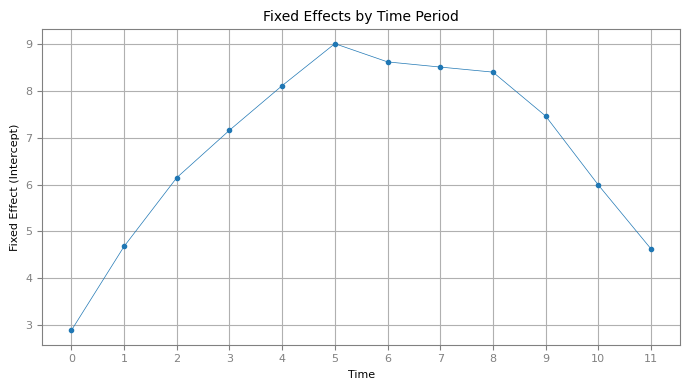

In [8]:

plt.figure(figsize=(7, 4))
plt.plot(range(max_time + 1), absolute_fixed_effects_df['fixed_effect'], marker='o')
plt.title("Fixed Effects by Time Period")
plt.xlabel("Time")
plt.ylabel("Fixed Effect (Intercept)")
plt.grid(True)
plt.xticks(range(max_time + 1))
plt.tight_layout()
plt.show()


### Question 2  
**10 Points**  

What about the fixed effect for each city (0 through 9). 

Option A
The effects increase from city 0 to about 4 or 5 but then eventually decrease again.

Option B
The effects decrease from city 0 to about 4 or 5 but then eventually increase again. 

Option C
The effects gradually increase from city 0 to 9.

Option D
The effects vary randomly.



In [9]:
# The formula is y ~ X + C(city)
model_formula_city = 'y ~ X + C(city)'
model_city = smf.ols(formula=model_formula_city, data=df)
results_city = model_city.fit()

# Extract the constant terms (fixed effects) for each city
fixed_effects_city = {}
# Get the intercept (fixed effect for the base category, which is city 0)
fixed_effects_city[0] = results_city.params['Intercept']

# Iterate through coefficients to find fixed effects for other cities
for i in range(1, 10): # Cities 0 through 9
    coeff_name = f'C(city)[T.{i}]'
    if coeff_name in results_city.params:
        fixed_effects_city[i] = results_city.params['Intercept'] + results_city.params[coeff_name]
    else:
        fixed_effects_city[i] = None # Should not happen for existing cities

fixed_effects_city_df = pd.DataFrame.from_dict(fixed_effects_city, orient='index', columns=['fixed_effect'])
fixed_effects_city_df.index.name = 'city'

print(f"Fixed Effects for each city (using smf.ols):\n{fixed_effects_city_df}")


Fixed Effects for each city (using smf.ols):
      fixed_effect
city              
0        11.029943
1         5.227050
2         7.921836
3        12.926031
4        11.296032
5        -0.057783
6         7.704997
7         3.257647
8         3.384002
9         5.450428


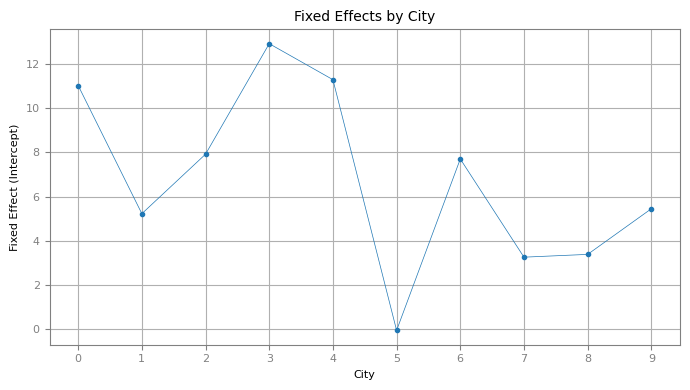

In [10]:
plt.figure(figsize = (7,4))
plt.plot(fixed_effects_city_df.index, fixed_effects_city_df['fixed_effect'], marker='o')
plt.title("Fixed Effects by City")
plt.xlabel("City")
plt.ylabel("Fixed Effect (Intercept)")
plt.grid(True)
plt.xticks(fixed_effects_city_df.index)
plt.tight_layout()
plt.show()

### Question 3  
**10 Points**  

For the following data, model `np.exp(Y)` as a function of X and Z. 

In [11]:

np.random.seed(42)

num = 10000

X   = np.clip(np.random.normal(3, 1, (num,)), 0.01, 100)

Z   = np.clip(np.random.normal(3, 1, (num,)), 0.01, 100)

Y   = np.log(X + Z) + np.random.normal(0, 1, (num,))


target      = np.exp(Y)

features    = np.column_stack((X, Z))

model   = sm.OLS(target, features)
results = model.fit()

coefficients = results.params
coefficients


array([1.65672559, 1.61760915])


With enough data, the coefficients of X and Y are closest to: 

Option A - Both 1 

Option B - Both 1.3 

Option C - `Both 1.6`

Option D -  Both 2.5

### Question 4  
**10 Points**  

Suppose we were to use the data below to find the standard error of X's coefficient (the coefficient that should be 1.5) in two ways: 

i) By asking Python to find the standard error. 

ii). 
       ```
                num = 10000 
                Z   = np.random.normal(0, 1, (num,)) 
                X   = Z + np.random.normal(0, 1, (num,)) 
                Y   = (1.5 * X) + (2.3 * Z) + np.random.normal(0, X**2, (num,))
        ```


In [15]:
num = 10000 
Z   = np.random.normal(0, 1, (num,)) 

X   = Z + np.random.normal(0, 1, (num,)) 

Y   = (1.5 * X) + (2.3 * Z) + np.random.normal(0, X ** 2, (num,)) 

In [13]:
np.random.seed(42)

# Number of samples
num = 10000

Z = np.random.normal(0, 1, num)
X = Z + np.random.normal(0, 1, num)
Y = 1.5 * X + 2.3 * Z + np.random.normal(0, X**2)

# Method (i): Estimate standard error from a single regression
X_single        = sm.add_constant(X)
model_single    = sm.OLS(Y, X_single).fit()
se_i            = model_single.bse[1]  # Standard error of X's coefficient

# Method (ii): Simulate 100 times and compute standard deviation of X's coefficient
coefficients = []
for _ in range(100):
    Z_sim = np.random.normal(0, 1, num)
    X_sim = Z_sim + np.random.normal(0, 1, num)
    Y_sim = 1.5 * X_sim + 2.3 * Z_sim + np.random.normal(0, X_sim**2)
    X_sim_const = sm.add_constant(X_sim)
    model_sim = sm.OLS(Y_sim, X_sim_const).fit()
    coefficients.append(model_sim.params[1])

se_ii = np.std(coefficients)

(se_i, se_ii)



(0.026407154953958425, 0.06664758709960769)

By simulating what happens if we generate the data 100 times, estimating X's coefficient and finding the standard deviation of the 100 estimates, then:

Option A. 
 (i) is significantly bigger than (ii), but neither is zero. 

Option B. 
They are about the same. 

Option C. 
`(ii) is significantly bigger than (i), but neither is zero.`


Option D. 
One or both of them are zero.



<font color='plum'>
The standard error from the simulation (method ii) is significantly larger than the one reported by the regression model (method i).
This discrepancy arises because the noise in the model depends on X², introducing heteroskedasticity (non-constant variance), which violates a key assumption of ordinary least squares (OLS). OLS underestimates the true variability in such cases.



Correct Answer:
Option C: (ii) is significantly bigger than (i), but neither is zero.